In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_3696/2669226731.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
First 5 records:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic            

In [3]:
# Rebuild the Class 2 preprocessed + split + scaled data

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
df_encoded = pd.get_dummies(df.drop('customerID', axis=1), columns=cat_cols, drop_first=True)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (5634, 30), Test shape: (1409, 30)


In [4]:
# =============================================================================
# TASK 1: Train Three Logistic Regression Models
# =============================================================================

# Step 2 — Model A: no regularization
model_a = LogisticRegression(penalty=None, max_iter=1000)
model_a.fit(X_train, y_train)

# Step 3 — Model B: L1 regularization
model_b = LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=1000)
model_b.fit(X_train, y_train)

# Step 4 — Model C: L2 regularization
model_c = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
model_c.fit(X_train, y_train)

print("All three models trained.")

All three models trained.


In [5]:
# =============================================================================
# TASK 2: Compare Performance
# =============================================================================

# Step 1 — Evaluate all three models
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    }

results = [
    evaluate(model_a, X_test, y_test, 'No Regularization'),
    evaluate(model_b, X_test, y_test, 'L1 (Lasso)'),
    evaluate(model_c, X_test, y_test, 'L2 (Ridge)')
]

performance_df = pd.DataFrame(results).set_index('Model')
print(performance_df)
performance_df

                   Accuracy  Precision    Recall        F1       AUC
Model                                                               
No Regularization  0.801278   0.647799  0.550802  0.595376  0.840693
L1 (Lasso)         0.801987   0.648903  0.553476  0.597403  0.842473
L2 (Ridge)         0.805536   0.657233  0.558824  0.604046  0.842068


,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
No Regularization,0.801278,0.647799,0.550802,0.595376,0.840693
L1 (Lasso),0.801987,0.648903,0.553476,0.597403,0.842473
L2 (Ridge),0.805536,0.657233,0.558824,0.604046,0.842068


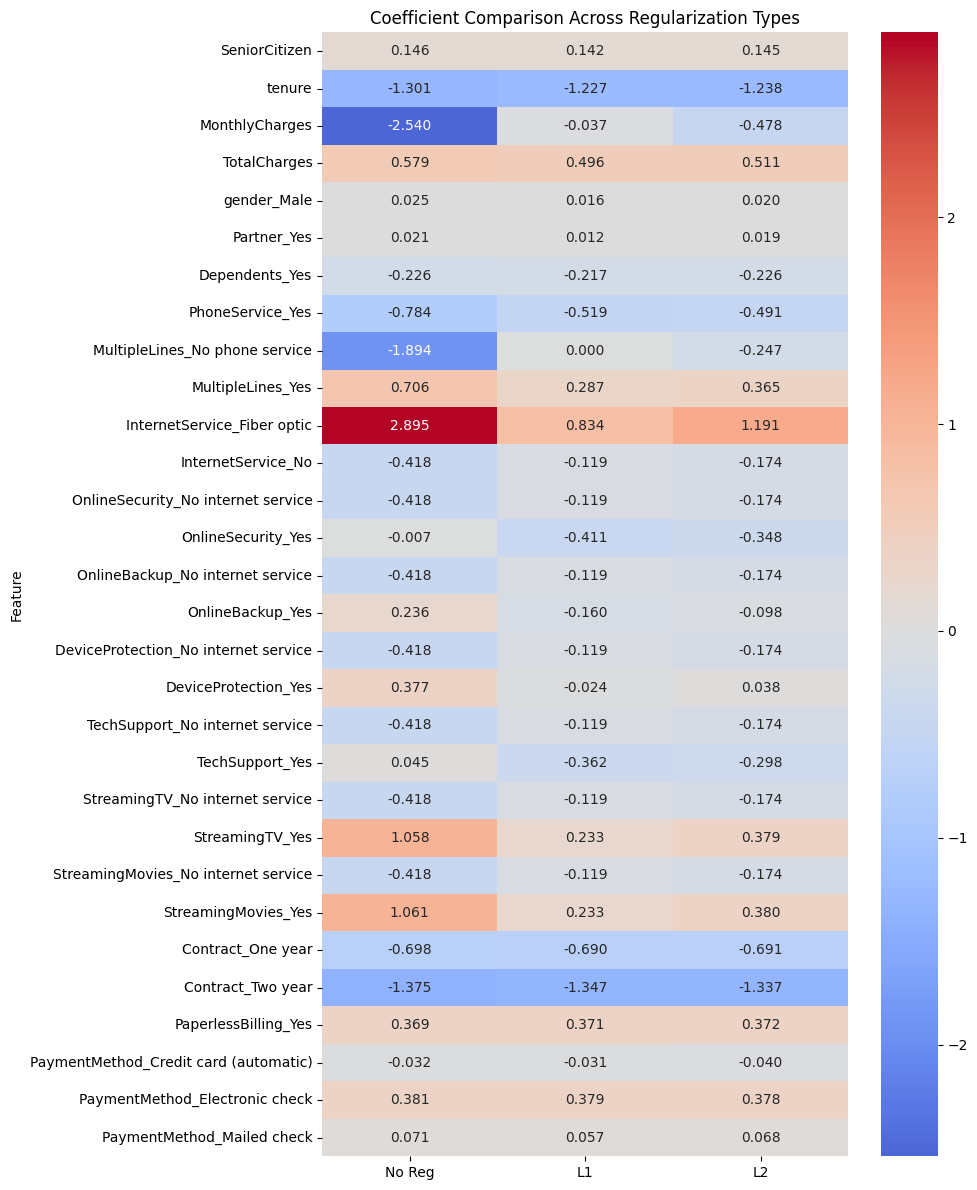

No Reg: 30 non-zero coefficients out of 30
L1: 29 non-zero coefficients out of 30
L2: 30 non-zero coefficients out of 30
L1 zeroed out 1 features:
  - MultipleLines_No phone service


In [6]:
# =============================================================================
# TASK 3: Compare Coefficients
# =============================================================================

# Step 1 — Extract coefficients from all three models
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'No Reg': model_a.coef_[0],
    'L1': model_b.coef_[0],
    'L2': model_c.coef_[0]
})
coef_df.head(10)

# Step 2 — Heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(coef_df.set_index('Feature'), annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Coefficient Comparison Across Regularization Types')
plt.tight_layout()
plt.show()

# Step 3 — Count non-zero coefficients for each model
for name, model in [('No Reg', model_a), ('L1', model_b), ('L2', model_c)]:
    n_nonzero = np.sum(model.coef_[0] != 0)
    print(f"{name}: {n_nonzero} non-zero coefficients out of {len(model.coef_[0])}")

# Step 4 — Identify which features L1 set to zero
zeroed_by_l1 = coef_df[coef_df['L1'] == 0]['Feature'].tolist()
print(f"L1 zeroed out {len(zeroed_by_l1)} features:")
for feat in zeroed_by_l1:
    print(f"  - {feat}")

if len(zeroed_by_l1) == 0:
    print("No features were zeroed out at C=1.0 — try a smaller C "
          "(stronger regularization) to see L1's feature-selection effect more clearly.")

      C       F1  Large Coefficients (|coef| > 0.1)
  0.001 0.306034                                  9
  0.010 0.553655                                 26
  0.100 0.589781                                 25
  1.000 0.604046                                 24
 10.000 0.604046                                 25
100.000 0.596237                                 24


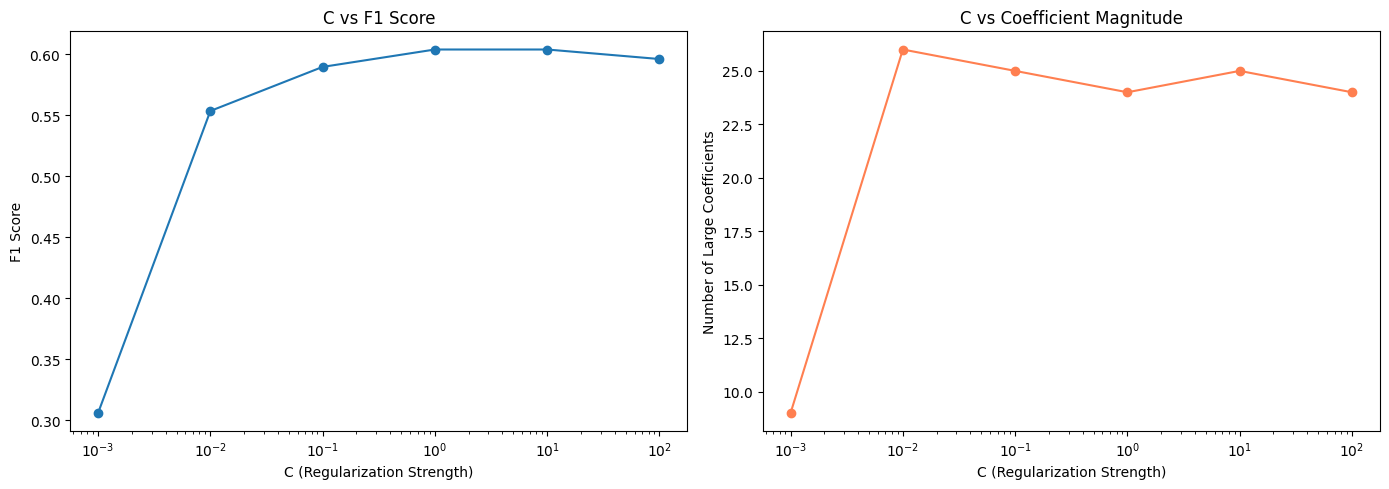

In [8]:
# =============================================================================
# TASK 4: Vary Regularization Strength
# =============================================================================

# Step 1 — Train L2 models across a range of C values
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
f1_scores = []
n_large_coefs = []

for C in C_values:
    model = LogisticRegression(penalty='l2', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1_scores.append(f1_score(y_test, y_pred))
    n_large_coefs.append(np.sum(np.abs(model.coef_[0]) > 0.1))

c_sweep_df = pd.DataFrame({
    'C': C_values, 'F1': f1_scores, 'Large Coefficients (|coef| > 0.1)': n_large_coefs
})
print(c_sweep_df.to_string(index=False))

# Step 2 — Plot C vs F1 and C vs coefficient magnitude
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(C_values, f1_scores, 'o-')
ax1.set_xscale('log')
ax1.set_xlabel('C (Regularization Strength)')
ax1.set_ylabel('F1 Score')
ax1.set_title('C vs F1 Score')

ax2.plot(C_values, n_large_coefs, 'o-', color='coral')
ax2.set_xscale('log')
ax2.set_xlabel('C (Regularization Strength)')
ax2.set_ylabel('Number of Large Coefficients')
ax2.set_title('C vs Coefficient Magnitude')

plt.tight_layout()
plt.show()

# Step 3 — Identify the sweet spot
best_c_row = c_sweep_df.loc[c_sweep_df['F1'].idxmax()]
